In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/Housing.csv')

In [2]:
# Quick overview
print(df.shape)
print(df.info())
print(df.describe().T)
display(df.head())

# Check categorical columns
print(df.select_dtypes(include='object').head())

# Check Missing or Duplicate Data
print("Missing values:\n", df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())

(545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
           count          mean           std        min        25%        50%  \
price      545.0  4.766729e+06  1.870440e+06  1750000.0  3

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


  mainroad guestroom basement hotwaterheating airconditioning prefarea  \
0      yes        no       no              no             yes      yes   
1      yes        no       no              no             yes       no   
2      yes        no      yes              no              no      yes   
3      yes        no      yes              no             yes      yes   
4      yes       yes      yes              no             yes       no   

  furnishingstatus  
0        furnished  
1        furnished  
2   semi-furnished  
3        furnished  
4        furnished  
Missing values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Duplicate rows: 0


In [3]:
# Examine Categorical Features
for col in ['mainroad','guestroom','basement','hotwaterheating',
            'airconditioning','prefarea','furnishingstatus']:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for mainroad:
mainroad
yes    468
no      77
Name: count, dtype: int64

Value counts for guestroom:
guestroom
no     448
yes     97
Name: count, dtype: int64

Value counts for basement:
basement
no     354
yes    191
Name: count, dtype: int64

Value counts for hotwaterheating:
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

Value counts for airconditioning:
airconditioning
no     373
yes    172
Name: count, dtype: int64

Value counts for prefarea:
prefarea
no     417
yes    128
Name: count, dtype: int64

Value counts for furnishingstatus:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


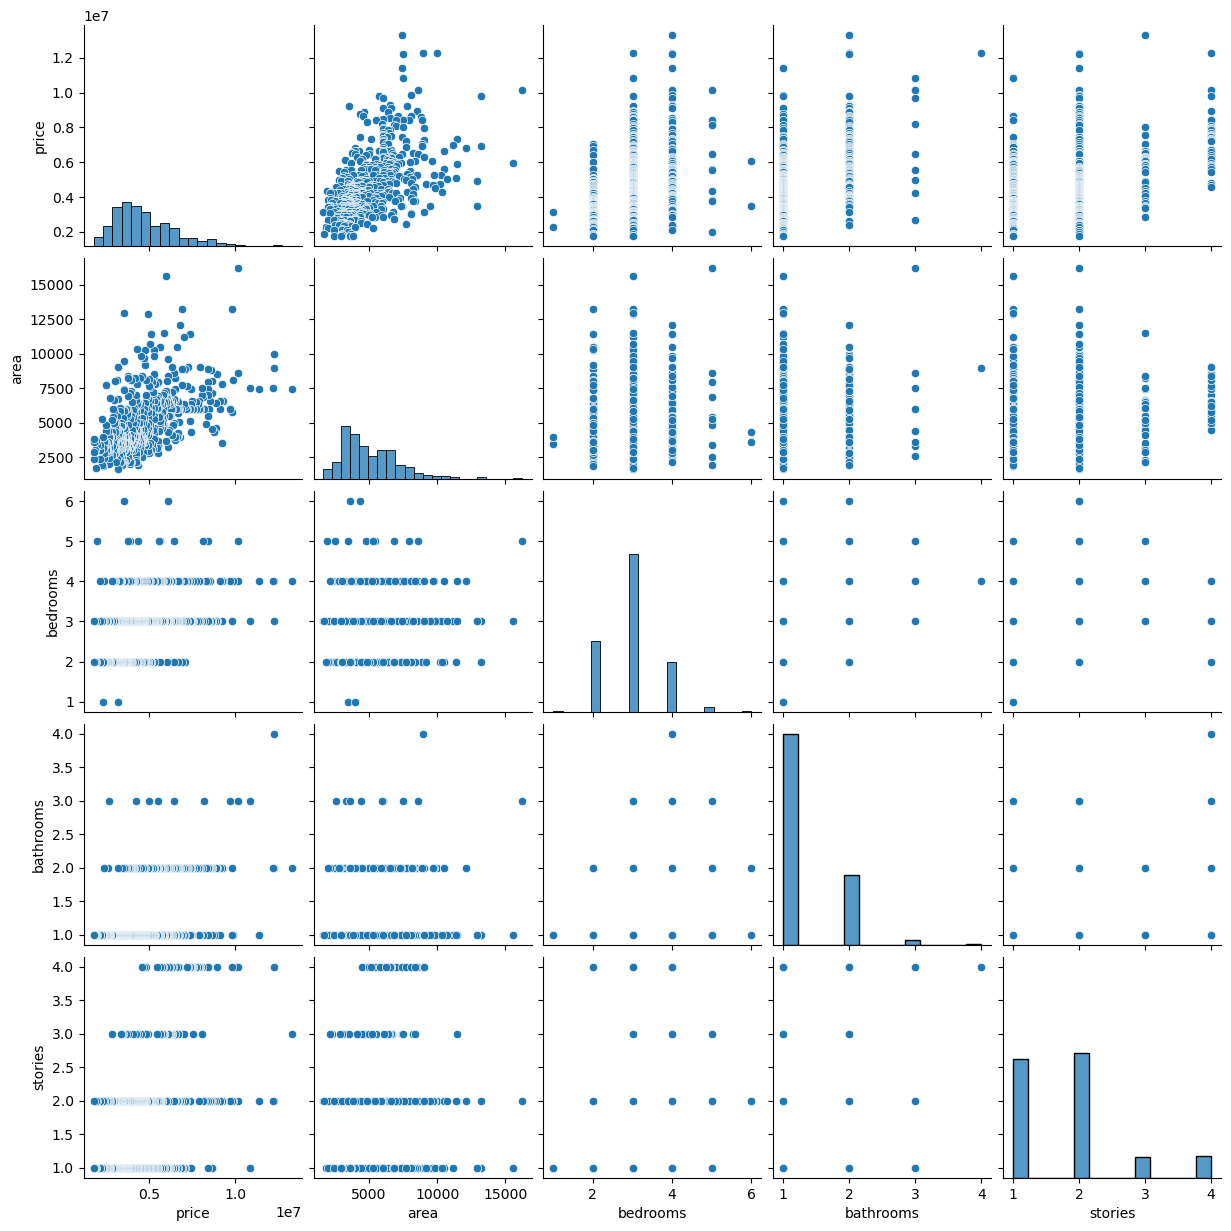

In [4]:
sns.pairplot(df[['price', 'area', 'bedrooms', 'bathrooms', 'stories']])
plt.savefig("../visualizations/initial eda/num_pairplot.png", dpi=300)
plt.show()

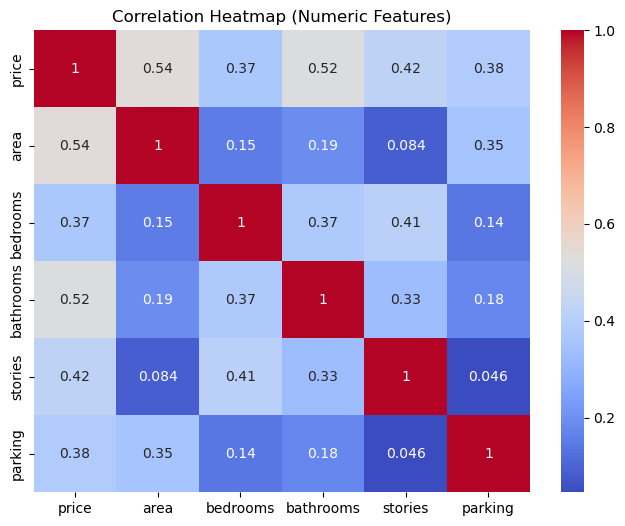

In [5]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.savefig("../visualizations/initial eda/corr_heatmap.png", dpi=300)
plt.show()

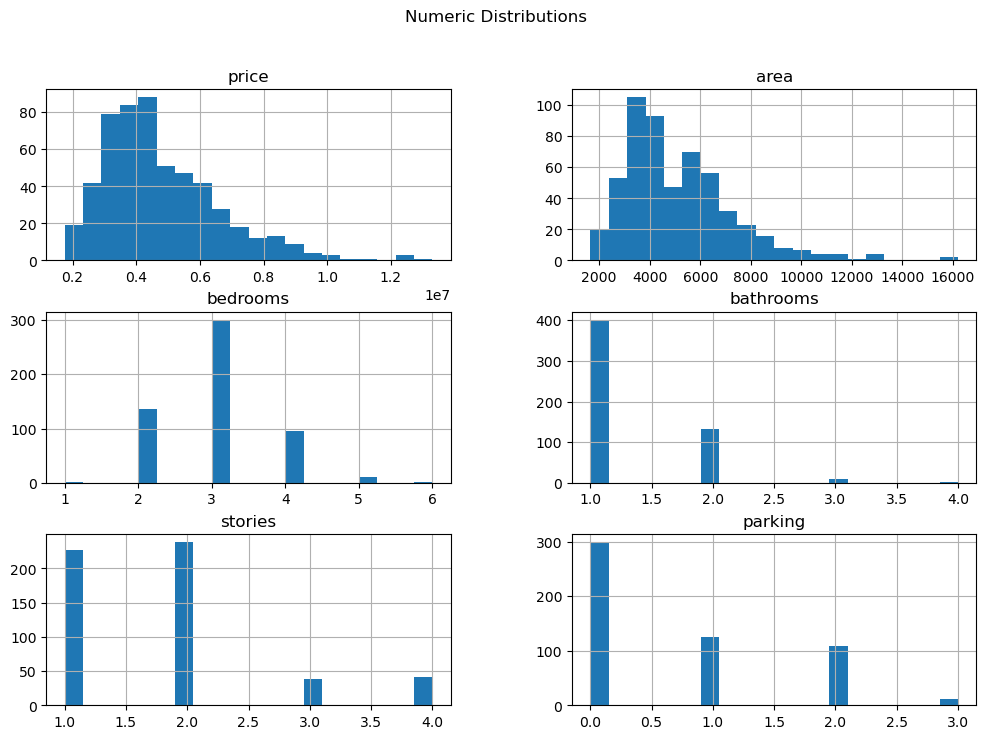

In [6]:
# Distributions and Outliers
num_cols = ['price','area','bedrooms','bathrooms','stories','parking']
df[num_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Numeric Distributions")
plt.savefig("../visualizations/initial eda/num_distributions.png", dpi=300)
plt.show()

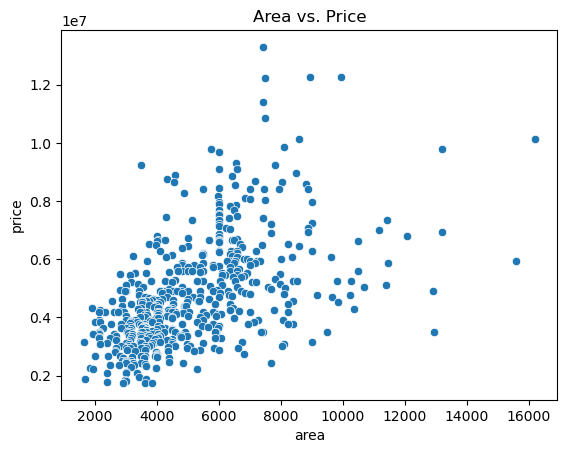

In [7]:
# Feature Relationships
sns.scatterplot(x='area', y='price', data=df)
plt.title("Area vs. Price")
plt.savefig("../visualizations/initial eda/area_vs_price.png", dpi=300)
plt.show()

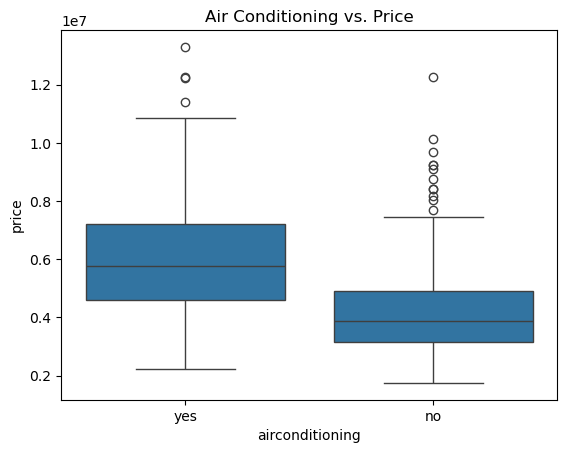

In [8]:
# Categorical influence
sns.boxplot(x='airconditioning', y='price', data=df)
plt.title("Air Conditioning vs. Price")
plt.savefig("../visualizations/initial eda/conditioning_vs_price.png", dpi=300)
plt.show()